In [17]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
df_reviews = pd.read_csv('reviews_all_cities.csv' ,nrows=50000)
df_reviews = df_reviews.dropna(subset=['comments']).copy()

 # print(f"Total valid reviews loaded: {len(df_reviews)}")
df_reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,city
0,17994,24905,2010-01-26,70562,Claudia,Reems apartment is perfectly located in a quie...,paris
1,21004,31284,2010-03-25,80094,Sean,"Dear traveler, consider yourself as lucky if y...",paris
2,21167,33980,2010-04-06,73119,Emily & Matt,Isabelle was a lovely host! She was extremely ...,paris
3,24260,34296,2010-04-08,98994,Esther,"Emmanuel's appartment was really nice, modern ...",paris
4,24260,35586,2010-04-14,100405,Naomi,We stayed at Emmanuel’s apartment in April 201...,paris


In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
        
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    tokens = word_tokenize(text)
#     cleaned_tokens = []
# for word in tokens:
#     if word not in stop_words and len(word) > 2:
#         lemma_word = lemmatizer.lemmatize(word)
#         cleaned_tokens.append(lemma_word)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(cleaned_tokens)

print("Preprocessing function successfully defined!")

Preprocessing function successfully defined!


In [11]:
df_reviews['clean_comments'] = df_reviews['comments'].apply(clean_text)
df_reviews = df_reviews[df_reviews['clean_comments'].str.len() > 3].reset_index(drop=True)
print(f"Total processed clean reviews: {len(df_reviews)}")
df_reviews[['comments', 'clean_comments']].head()

Total processed clean reviews: 49589


,comments,clean_comments
0,Reems apartment is perfectly located in a quie...,reems apartment perfectly located quiet upscal...
1,"Dear traveler, consider yourself as lucky if y...",dear traveler consider lucky came across prope...
2,Isabelle was a lovely host! She was extremely ...,isabelle lovely host extremely helpful arrived...
3,"Emmanuel's appartment was really nice, modern ...",emmanuels appartment really nice modern clean ...
4,We stayed at Emmanuel’s apartment in April 201...,stayed emmanuels apartment april really impres...


In [12]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'
df_reviews['sentiment_score'] = df_reviews['clean_comments'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_reviews['sentiment_label'] = df_reviews['sentiment_score'].apply(get_sentiment)
print("--- Sentiment Distribution Summary ---")
print(df_reviews['sentiment_label'].value_counts())

df_reviews[['comments', 'sentiment_score', 'sentiment_label']].head()


--- Sentiment Distribution Summary ---
sentiment_label
Positive    40595
Neutral      5400
Negative     3594
Name: count, dtype: int64


,comments,sentiment_score,sentiment_label
0,Reems apartment is perfectly located in a quie...,0.9801,Positive
1,"Dear traveler, consider yourself as lucky if y...",0.9980,Positive
2,Isabelle was a lovely host! She was extremely ...,0.9694,Positive
3,"Emmanuel's appartment was really nice, modern ...",0.9727,Positive
4,We stayed at Emmanuel’s apartment in April 201...,0.9843,Positive


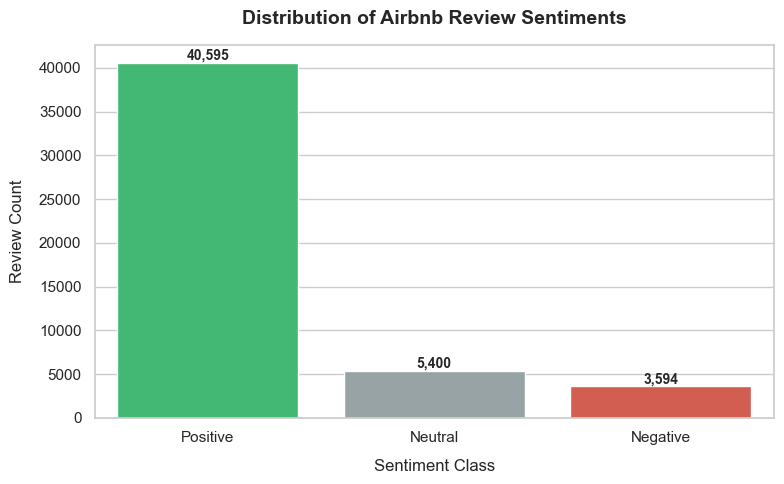

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot sentiment label counts
palette = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
ax = sns.countplot(data=df_reviews, x='sentiment_label', palette=palette, order=['Positive', 'Neutral', 'Negative'])

plt.title('Distribution of Airbnb Review Sentiments', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Class', fontsize=12, labelpad=10)
plt.ylabel('Review Count', fontsize=12, labelpad=10)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

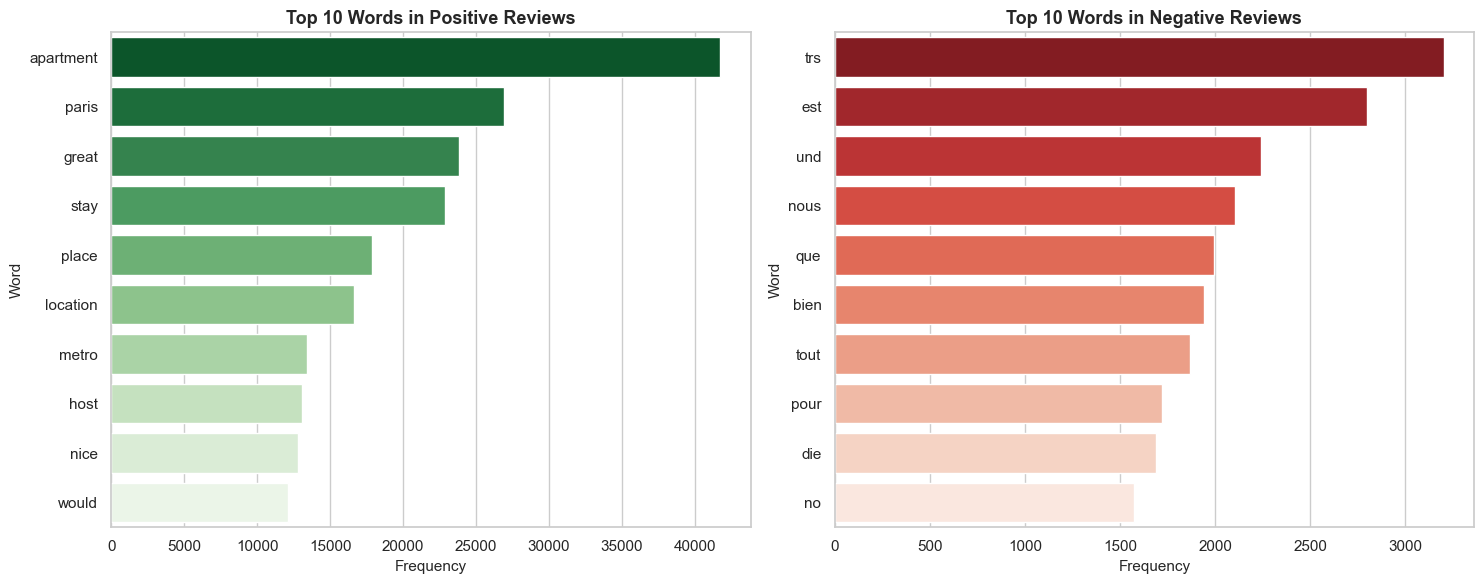

In [24]:
from collections import Counter

pos_comments = df_reviews[df_reviews['sentiment_label'] == 'Positive']['clean_comments']
neg_comments = df_reviews[df_reviews['sentiment_label'] == 'Negative']['clean_comments']

pos_words = Counter(" ".join(pos_comments).split()).most_common(10)
neg_words = Counter(" ".join(neg_comments).split()).most_common(10)

df_pos_words = pd.DataFrame(pos_words, columns=['word', 'count'])
df_neg_words = pd.DataFrame(neg_words, columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=df_pos_words, x='count', y='word', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Words in Positive Reviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].set_ylabel('Word', fontsize=11)

sns.barplot(data=df_neg_words, x='count', y='word', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Words in Negative Reviews', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].set_ylabel('Word', fontsize=11)

plt.tight_layout()
plt.show()